# Maze Route as an Energy-Based Model

We model a maze as categorical variables and sample low-energy states. The goal is not to mark every open corridor as `Path`; it is to mark only the start-to-end route and leave dead ends as `NotPath`.

## Mathematical Model

Let the maze grid be a graph $G=(V,E)$ with one categorical random variable per grid cell,

$$
x_i \in \mathcal C = \{P,N,W\},
$$

where $P$ means `Path`, $N$ means `NotPath`, and $W$ means `Wall`. THRML samples from the Boltzmann distribution

$$
p_\beta(x) = \frac{\exp(-E_\beta(x))}{Z},
\qquad
E_\beta(x) = -\beta S(x),
$$

with score

$$
S(x) = \sum_{i\in V} b_i[x_i]
     + \sum_{i\in V_	ext{open}} D_i(x_i, x_{\mathcal N(i)}).
$$

There is no edge-interaction matrix in this version. The route shape comes from node biases and the local degree-shell factor $D_i$, which relates a cell to its four neighbors.

## Factors

The node bias $b_i$ pins known cell types:

$$
b_i =
\begin{cases}
[-8,-8,12] & 	\text{if cell } i 	\text{ is a maze wall},\\
[5,-8,-8] & 	\text{if } i \in \{	\text{start},	\text{end}\},\\
[0,0,-8] & 	\text{otherwise.}
\end{cases}
$$

For an open cell, define its Path degree

$$
d_i(x)=\sum_{j\in\mathcal N(i)} \mathbf 1[x_j=P].
$$

The degree-shell factor rewards path geometry:

$$
D_i =
\begin{cases}
r_P & x_i=P 	\text{ and } d_i=1, && i \in \{	\text{start},	\text{end}\},\\
r_P & x_i=P 	\text{ and } d_i=2, && 	\text{ordinary open cell},\\
r_N & x_i=N 	\text{ and } d_i\le 1, && 	\text{ordinary open cell},\\
-\lambda & 	\text{otherwise.}
\end{cases}
$$

We use $r_P=0.5$, $r_N=0.55$, $\lambda=8$, and $\beta=2$ from `utils.config`. The factor touches a center cell and its four neighbors, so variables inside one factor can be two graph hops apart. The Gibbs schedule therefore uses a 5-color `two_hop` block scheme.

In [13]:
import jax
import matplotlib.pyplot as plt
import numpy as np
from thrml import SamplingSchedule

from utils import config, model, visualize
from utils.wrapper_maze import generate_maze, maze_to_graph

In [14]:
EBM_PARAMS = dict(
    bias_wall=config.BIAS_WALL,
    bias_goal=config.BIAS_GOAL,
    bias_other=config.BIAS_OTHER,
    block_scheme='two_hop',
)
DEGREE_PARAMS = dict(
    degree_path_reward=config.DEGREE_PATH_REWARD,
    degree_off_reward=config.DEGREE_OFF_REWARD,
    degree_penalty=config.DEGREE_PENALTY,
)
BETA = config.BETA
SCHEDULE = SamplingSchedule(
    n_warmup=config.N_WARMUP,
    n_samples=config.N_SAMPLES,
    steps_per_sample=config.STEPS_PER_SAMPLE,
)
EVOLUTION_SCHEDULE = SamplingSchedule(
    n_warmup=0,
    n_samples=config.N_SAMPLES,
    steps_per_sample=config.STEPS_PER_SAMPLE,
)

In [15]:
def solve_with_ebm(width, height, seed, key_seed=None, schedule=SCHEDULE):
    grid, start, end = generate_maze(width=width, height=height, seed=seed)
    mg = maze_to_graph(grid, start, end, **EBM_PARAMS)
    program = model.build_program(mg, beta=BETA, **DEGREE_PARAMS)

    # Start from the over-complete state: every open cell is Path, every wall is Wall.
    # The degree factor then prunes branches into NotPath.
    init_state = np.where(grid.reshape(-1) == 1, config.WALL, config.PATH).astype(np.uint8)
    states = model.run_sampling(
        jax.random.key(seed if key_seed is None else key_seed),
        mg,
        program,
        schedule,
        init_state=init_state,
    )
    energies = model.energy_of_states(mg, states, beta=BETA, **DEGREE_PARAMS)
    best_idx = np.unravel_index(np.argmin(energies), energies.shape)
    best_state = states[best_idx]

    target = model.shortest_path_mask(mg).reshape(-1)
    exact_samples = ((states == config.PATH) == target).all(axis=2)
    solved_samples = model.solved_matrix(mg, states)
    path_counts = (states == config.PATH).sum(axis=2)
    shortest_cells = int(target.sum())
    excess_path = path_counts - shortest_cells

    if solved_samples.any():
        solution_rank = np.where(solved_samples, excess_path, np.inf)
        best_solution_idx = np.unravel_index(np.argmin(solution_rank), solution_rank.shape)
        best_solution_state = states[best_solution_idx]
        best_solution_excess = int(excess_path[best_solution_idx])
    else:
        best_solution_state = None
        best_solution_excess = None

    nonexact_solution = solved_samples & ~exact_samples
    if nonexact_solution.any():
        nonexact_rank = np.where(nonexact_solution, excess_path, np.inf)
        best_nonexact_idx = np.unravel_index(np.argmin(nonexact_rank), nonexact_rank.shape)
        best_nonexact_solution_state = states[best_nonexact_idx]
        best_nonexact_solution_excess = int(excess_path[best_nonexact_idx])
        best_nonexact_solution_path_cells = int(path_counts[best_nonexact_idx])
    else:
        best_nonexact_solution_state = None
        best_nonexact_solution_excess = None
        best_nonexact_solution_path_cells = None

    path = best_state == config.PATH
    open_cells = grid.reshape(-1) == 0

    return dict(
        grid=grid,
        start=start,
        end=end,
        mg=mg,
        states=states,
        energies=energies,
        target_path=target.reshape(grid.shape),
        exact_samples=exact_samples,
        solved_samples=solved_samples,
        path_counts=path_counts,
        excess_path=excess_path,
        best_state=best_state,
        best_solution_state=best_solution_state,
        best_nonexact_solution_state=best_nonexact_solution_state,
        energy=float(energies[best_idx]),
        path_cells=int(path.sum()),
        shortest_cells=shortest_cells,
        exact_best=bool((path == target).all()),
        solved_best=bool(model.is_solved(mg, best_state)),
        exact_chains=int(exact_samples.any(axis=1).sum()),
        solved_chains=int(solved_samples.any(axis=1).sum()),
        best_solution_excess=best_solution_excess,
        best_nonexact_solution_excess=best_nonexact_solution_excess,
        best_nonexact_solution_path_cells=best_nonexact_solution_path_cells,
        extra_path=int((path & open_cells & ~target).sum()),
        missing_path=int((target & ~path).sum()),
    )

## One Maze

grid: (17, 17) | start: (9, 0) | end: (7, 16)
lowest energy: -3999.6
best state is connected: True
best state equals shortest route: True
path cells: 23
extra Path cells: 0
missing route cells: 0
chains that sampled a connected route: 17/32
chains that sampled the exact route: 17/32


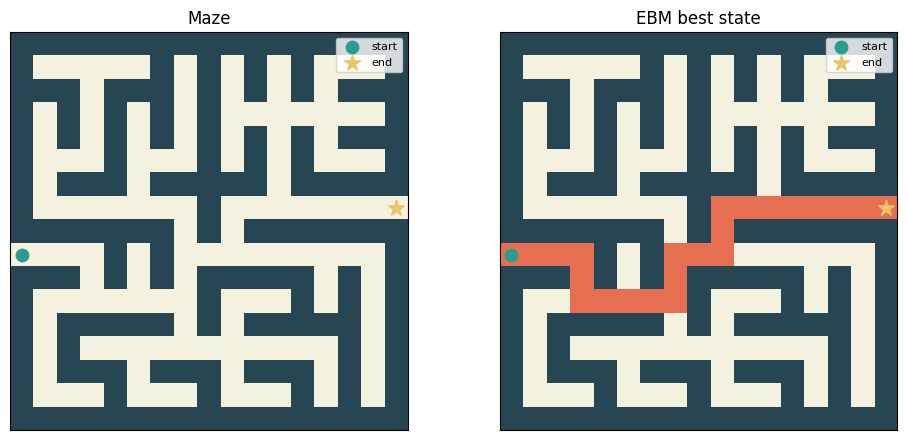

In [16]:
example = solve_with_ebm(width=8, height=8, seed=7)
print('grid:', example['grid'].shape, '| start:', example['start'], '| end:', example['end'])
print('lowest energy:', example['energy'])
print('best state is connected:', example['solved_best'])
print('best state equals shortest route:', example['exact_best'])
print('path cells:', example['path_cells'])
print('extra Path cells:', example['extra_path'])
print('missing route cells:', example['missing_path'])
print('chains that sampled a connected route:', f"{example['solved_chains']}/{config.N_CHAINS}")
print('chains that sampled the exact route:', f"{example['exact_chains']}/{config.N_CHAINS}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
visualize.plot_maze(example['grid'], example['start'], example['end'], ax=axes[0], title='Maze')
visualize.plot_state(example['mg'], example['best_state'], ax=axes[1], title='EBM best state')
fig.tight_layout();

## Sampling Evolution

This run records from step 0 instead of discarding warmup. The first snapshot is still close to the flooded initialization; later snapshots show the degree factor pruning dead-end branches.

sample steps: [0, 1, 2, 5, 10, 50, 199]
Path cells in chain 0: [129, 77, 65, 59, 47, 23, 23]
lowest-energy state equals shortest route: True


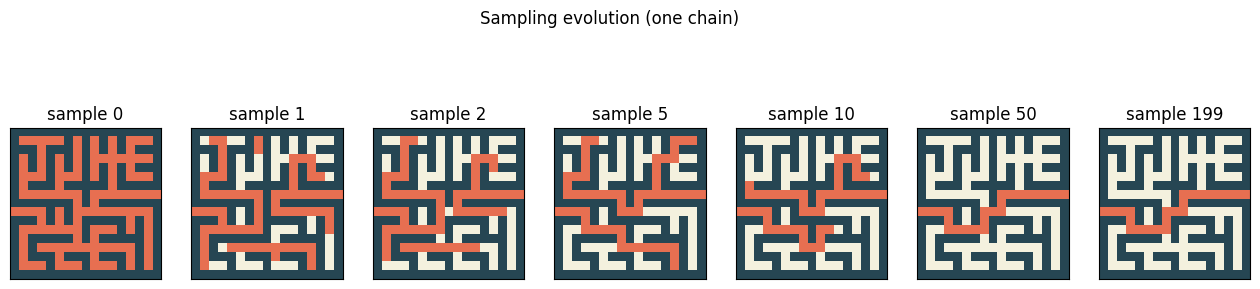

In [17]:
evolution = solve_with_ebm(width=8, height=8, seed=7, schedule=EVOLUTION_SCHEDULE)
sample_steps = [0, 1, 2, 5, 10, 50, config.N_SAMPLES - 1]
path_counts = [int((evolution['states'][0, t] == config.PATH).sum()) for t in sample_steps]
print('sample steps:', sample_steps)
print('Path cells in chain 0:', path_counts)
print('lowest-energy state equals shortest route:', evolution['exact_best'])
visualize.plot_sampling_evolution(evolution['mg'], evolution['states'][0], sample_steps,
                                  figsize=(16, 4));

## Energy and Convergence Diagnostics

The no-warmup run makes the relaxation visible. A sample counts as **solved** if its Path cells connect start to end; it counts as **exact** only if those Path cells are exactly the shortest route. Solved-but-not-exact samples are still useful solutions, just not optimal.

chains that ever hit a connected route: 32/32
chains that ever hit exact route: 23/32
first solved sample: median 0 | min 0 | max 0
first exact sample: median 39 | min 13 | max 86


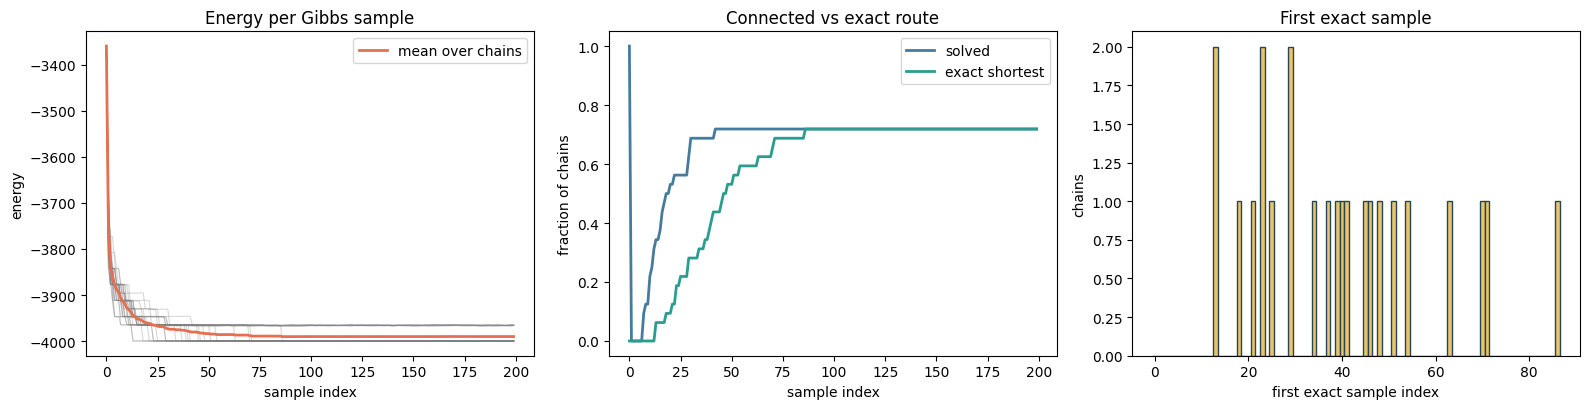

In [18]:
exact = evolution['exact_samples']
solved = evolution['solved_samples']
ever_exact = exact.any(axis=1)
ever_solved = solved.any(axis=1)
first_exact = np.where(ever_exact, exact.argmax(axis=1), -1)
first_solved = np.where(ever_solved, solved.argmax(axis=1), -1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
visualize.plot_energy_trace(evolution['energies'], ax=axes[0], title='Energy per Gibbs sample')
axes[1].plot(solved.mean(axis=0), color='#457b9d', lw=2, label='solved')
axes[1].plot(exact.mean(axis=0), color='#2a9d8f', lw=2, label='exact shortest')
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel('sample index')
axes[1].set_ylabel('fraction of chains')
axes[1].set_title('Connected vs exact route')
axes[1].legend()
if ever_exact.any():
    axes[2].hist(first_exact[ever_exact], bins=np.arange(first_exact[ever_exact].max() + 2) - 0.5,
                 color='#e9c46a', edgecolor='#264653')
axes[2].set_xlabel('first exact sample index')
axes[2].set_ylabel('chains')
axes[2].set_title('First exact sample')
fig.tight_layout()

print('chains that ever hit a connected route:', f'{ever_solved.sum()}/{len(ever_solved)}')
print('chains that ever hit exact route:', f'{ever_exact.sum()}/{len(ever_exact)}')
if ever_solved.any():
    print('first solved sample: median', int(np.median(first_solved[ever_solved])),
          '| min', int(first_solved[ever_solved].min()),
          '| max', int(first_solved[ever_solved].max()))
if ever_exact.any():
    print('first exact sample: median', int(np.median(first_exact[ever_exact])),
          '| min', int(first_exact[ever_exact].min()),
          '| max', int(first_exact[ever_exact].max()))

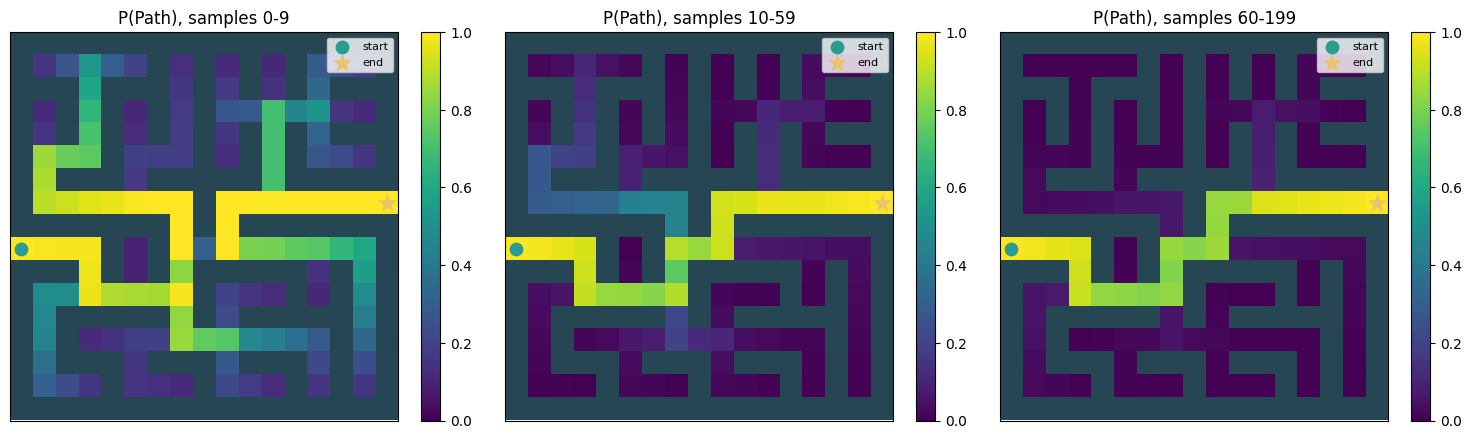

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
visualize.plot_path_marginal(
    evolution['mg'], evolution['states'][:, :10], ax=axes[0],
    title='P(Path), samples 0-9'
)
visualize.plot_path_marginal(
    evolution['mg'], evolution['states'][:, 10:60], ax=axes[1],
    title='P(Path), samples 10-59'
)
visualize.plot_path_marginal(
    evolution['mg'], evolution['states'][:, 60:], ax=axes[2],
    title='P(Path), samples 60-199'
)
fig.tight_layout();

## Solution Quality Beyond Optimality

For non-exact samples, we still track whether they are connected solutions and how many extra Path cells they carry relative to the shortest route. Lower excess is better; zero excess means exact shortest.

final connected solutions: 23/32
final exact shortest solutions: 23/32
final solved but not exact: 0/32
median excess Path cells among final solved: 0
best connected sample excess Path cells: 0
best connected non-exact sample path cells: 24
best connected non-exact sample excess Path cells: 1


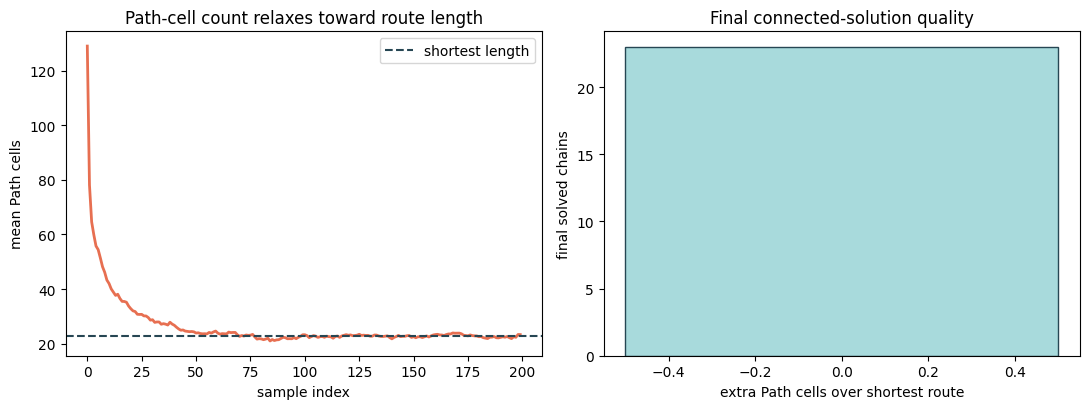

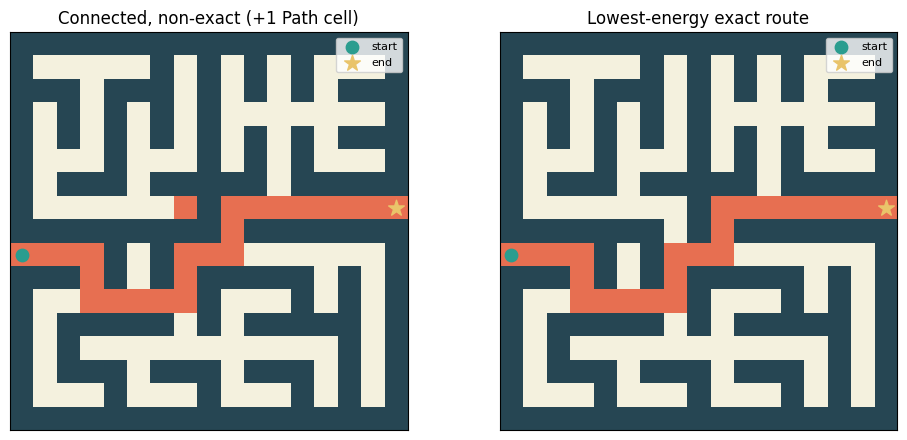

In [20]:
final_solved = evolution['solved_samples'][:, -1]
final_exact = evolution['exact_samples'][:, -1]
final_excess = evolution['excess_path'][:, -1]
solved_not_exact = final_solved & ~final_exact

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(evolution['path_counts'].mean(axis=0), color='#e76f51', lw=2)
axes[0].axhline(evolution['shortest_cells'], color='#264653', ls='--', lw=1.5,
                label='shortest length')
axes[0].set_xlabel('sample index')
axes[0].set_ylabel('mean Path cells')
axes[0].set_title('Path-cell count relaxes toward route length')
axes[0].legend()

if final_solved.any():
    axes[1].hist(final_excess[final_solved], bins=np.arange(final_excess[final_solved].max() + 2) - 0.5,
                 color='#a8dadc', edgecolor='#264653')
axes[1].set_xlabel('extra Path cells over shortest route')
axes[1].set_ylabel('final solved chains')
axes[1].set_title('Final connected-solution quality')
fig.tight_layout()

print('final connected solutions:', f'{final_solved.sum()}/{len(final_solved)}')
print('final exact shortest solutions:', f'{final_exact.sum()}/{len(final_exact)}')
print('final solved but not exact:', f'{solved_not_exact.sum()}/{len(solved_not_exact)}')
if final_solved.any():
    print('median excess Path cells among final solved:', int(np.median(final_excess[final_solved])))
    print('best connected sample excess Path cells:', evolution['best_solution_excess'])
if evolution['best_nonexact_solution_state'] is not None:
    print('best connected non-exact sample path cells:', evolution['best_nonexact_solution_path_cells'])
    print('best connected non-exact sample excess Path cells:', evolution['best_nonexact_solution_excess'])

if evolution['best_nonexact_solution_state'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    visualize.plot_state(
        evolution['mg'], evolution['best_nonexact_solution_state'], ax=axes[0],
        title=f"Connected, non-exact (+{evolution['best_nonexact_solution_excess']} Path cell)"
    )
    visualize.plot_state(
        evolution['mg'], evolution['best_state'], ax=axes[1],
        title='Lowest-energy exact route'
    )
    fig.tight_layout();

## Step Count Against Graph Search

For the sampler, a step is a recorded sample index, matching the sampling-evolution plots. For BFS, DFS, and A*, a step is the first visit to a new open grid cell; the start cell counts as step 1.

In [21]:
from collections import deque
import heapq


def open_neighbors(grid, cell):
    r, c = cell
    for nb in ((r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)):
        if 0 <= nb[0] < grid.shape[0] and 0 <= nb[1] < grid.shape[1] and grid[nb] == 0:
            yield nb


def graph_search_steps(grid, start, end, method):
    visited = set()

    if method == 'BFS':
        frontier = deque([start])
        seen = {start}
        pop = frontier.popleft
        push = frontier.append
    elif method == 'DFS':
        frontier = [start]
        seen = {start}
        pop = frontier.pop
        push = frontier.append
    elif method == 'A*':
        counter = 0
        heuristic = lambda cell: abs(cell[0] - end[0]) + abs(cell[1] - end[1])
        best_cost = {start: 0}
        frontier = [(heuristic(start), 0, counter, start)]
    else:
        raise ValueError(method)

    while frontier:
        if method == 'A*':
            _, cost, _, cell = heapq.heappop(frontier)
            if cost != best_cost[cell]:
                continue
        else:
            cell = pop()
            cost = 0
        if cell in visited:
            continue
        visited.add(cell)
        if cell == end:
            return len(visited)

        for nb in open_neighbors(grid, cell):
            if method == 'A*':
                nb_cost = cost + 1
                if nb_cost >= best_cost.get(nb, np.inf):
                    continue
                best_cost[nb] = nb_cost
                counter += 1
                heapq.heappush(frontier, (nb_cost + heuristic(nb), nb_cost, counter, nb))
            elif nb not in seen:
                seen.add(nb)
                push(nb)

    return None


def first_hit_summary(mask):
    ever = mask.any(axis=1)
    first = np.where(ever, mask.argmax(axis=1), -1)
    if not ever.any():
        return None
    hits = first[ever]
    return int(np.median(hits)), int(hits.min()), int(hits.max())


rows = []
solved_hit = first_hit_summary(evolution['solved_samples'])
exact_hit = first_hit_summary(evolution['exact_samples'])
if solved_hit is not None:
    rows.append(('EBM connected', 'sample index', solved_hit[0], f'min {solved_hit[1]}, max {solved_hit[2]}'))
if exact_hit is not None:
    rows.append(('EBM exact shortest', 'sample index', exact_hit[0], f'min {exact_hit[1]}, max {exact_hit[2]}'))

for method in ('BFS', 'DFS', 'A*'):
    rows.append((method, 'new open cells visited', graph_search_steps(evolution['grid'], evolution['start'], evolution['end'], method), ''))

print(f"{'method':<20} {'step unit':<23} {'steps':>7}  notes")
for method, unit, steps, notes in rows:
    print(f"{method:<20} {unit:<23} {steps:>7}  {notes}")

method               step unit                 steps  notes
EBM connected        sample index                  0  min 0, max 0
EBM exact shortest   sample index                 39  min 13, max 86
BFS                  new open cells visited       97  
DFS                  new open cells visited       63  
A*                   new open cells visited       33  


## Final State Probabilities

At the last recorded sample, each cell has an empirical probability of being `Path`, `NotPath`, or `Wall` across the parallel chains.

mean final P(Path): 0.081
mean final P(NotPath): 0.366
mean final P(Wall): 0.554


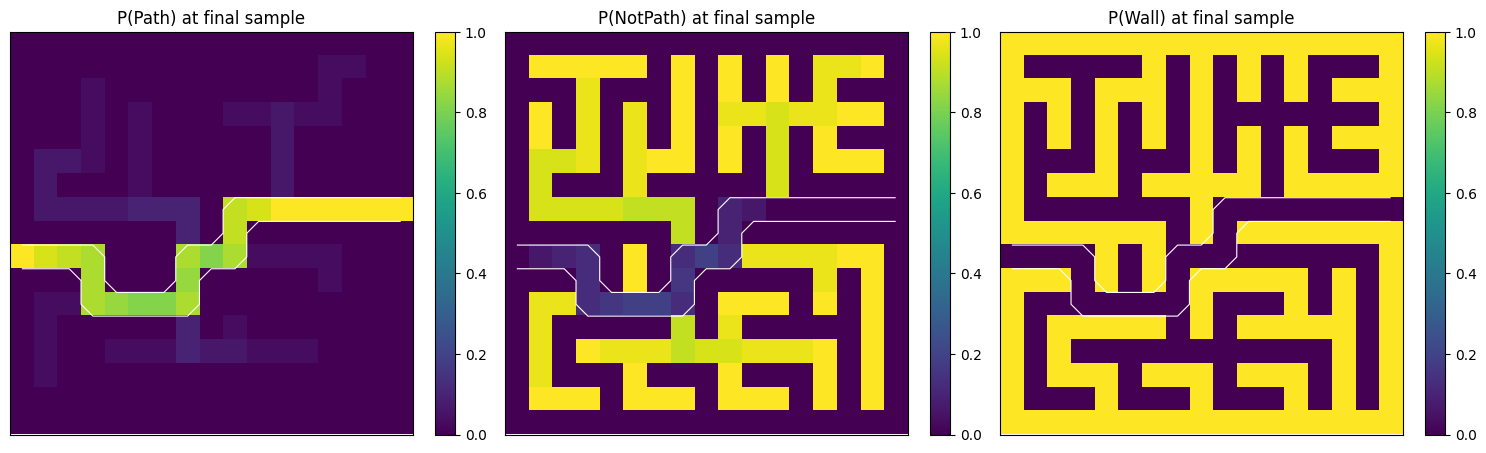

In [22]:
def plot_final_state_probabilities(result):
    final_states = result['states'][:, -1]
    fig, axes = plt.subplots(1, config.N_STATES, figsize=(15, 4.4))
    for state, ax in enumerate(axes):
        prob = (final_states == state).mean(axis=0).reshape(result['grid'].shape)
        im = ax.imshow(prob, cmap='viridis', vmin=0, vmax=1)
        ax.contour(result['target_path'], levels=[0.5], colors='white', linewidths=0.8)
        ax.set_title(f'P({config.STATE_NAMES[state]}) at final sample')
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    return fig

plot_final_state_probabilities(evolution);

final_states = evolution['states'][:, -1]
print('mean final P(Path):', f'{(final_states == config.PATH).mean():.3f}')
print('mean final P(NotPath):', f'{(final_states == config.NOT_PATH).mean():.3f}')
print('mean final P(Wall):', f'{(final_states == config.WALL).mean():.3f}')

## Different Seeds and Sizes

In [23]:
cases = [
    dict(width=4, height=4, seed=1),
    dict(width=5, height=5, seed=3),
    dict(width=8, height=8, seed=7),
    dict(width=10, height=10, seed=12),
]
examples = [solve_with_ebm(**case) for case in cases]

print(f"{'maze':>7} {'seed':>4} {'shortest':>8} {'path':>5} {'solved':>7} {'exact':>7} {'solved chains':>13} {'exact chains':>12} {'extra':>5} {'missing':>7}")
for case, result in zip(cases, examples):
    maze_name = f"{case['width']}x{case['height']}"
    print(f"{maze_name:>7} {case['seed']:>4} {result['shortest_cells']:>8} "
          f"{result['path_cells']:>5} {str(result['solved_best']):>7} {str(result['exact_best']):>7} "
          f"{result['solved_chains']:>5}/{config.N_CHAINS:<7} "
          f"{result['exact_chains']:>5}/{config.N_CHAINS:<6} "
          f"{result['extra_path']:>5} {result['missing_path']:>7}")

   maze seed shortest  path  solved   exact solved chains exact chains extra missing
    4x4    1       11    11    True    True    32/32         32/32         0       0
    5x5    3       25    25    True    True    28/32         28/32         0       0
    8x8    7       23    23    True    True    17/32         17/32         0       0
  10x10   12       39    39    True    True     9/32          9/32         0       0


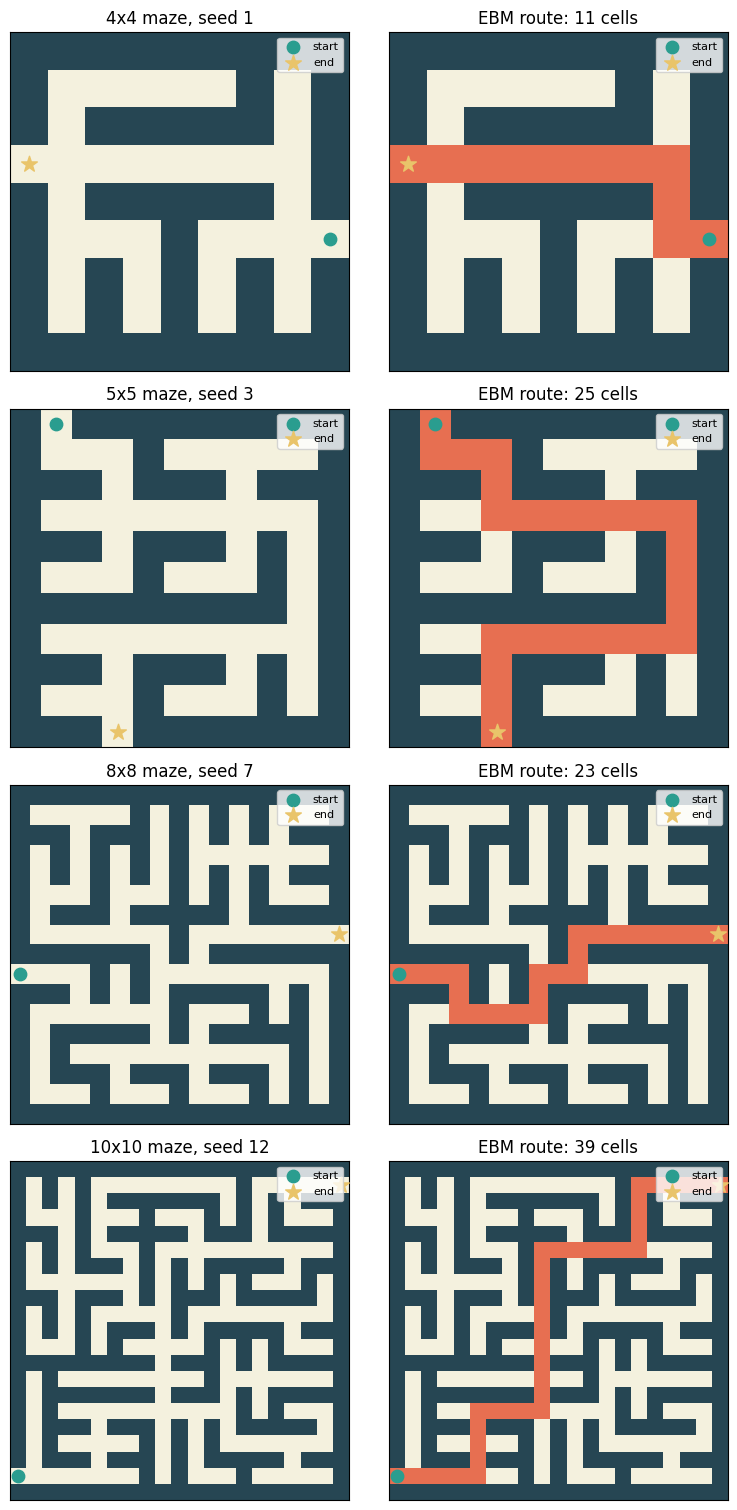

In [24]:
fig, axes = plt.subplots(len(examples), 2, figsize=(8, 3.8 * len(examples)))
for row, (case, result) in enumerate(zip(cases, examples)):
    visualize.plot_maze(
        result['grid'], result['start'], result['end'], ax=axes[row, 0],
        title=f"{case['width']}x{case['height']} maze, seed {case['seed']}"
    )
    visualize.plot_state(
        result['mg'], result['best_state'], ax=axes[row, 1],
        title=f"EBM route: {result['path_cells']} cells"
    )
fig.tight_layout();

## Notes

The sampler is stochastic, so not every chain has to land on the exact route. We select the lowest-energy sampled state. In these examples that state is the shortest start-to-end route and has no dead-end Path cells.